In [19]:
%pip install pandas
import pandas as pd

df = pd.read_csv("../data/raw_data.csv", encoding="latin1")

df.head()
df.info()


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9

In [20]:
df.isnull().sum()
df.duplicated().sum()
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [21]:
df = df.drop_duplicates()

In [22]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [23]:
df['order_year'] = df['Order Date'].dt.year
df['order_month'] = df['Order Date'].dt.to_period('M')
df['profit_margin'] = df['Profit'] / df['Sales']

In [24]:
df.to_csv("../data/cleaned_data.csv", index=False)


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


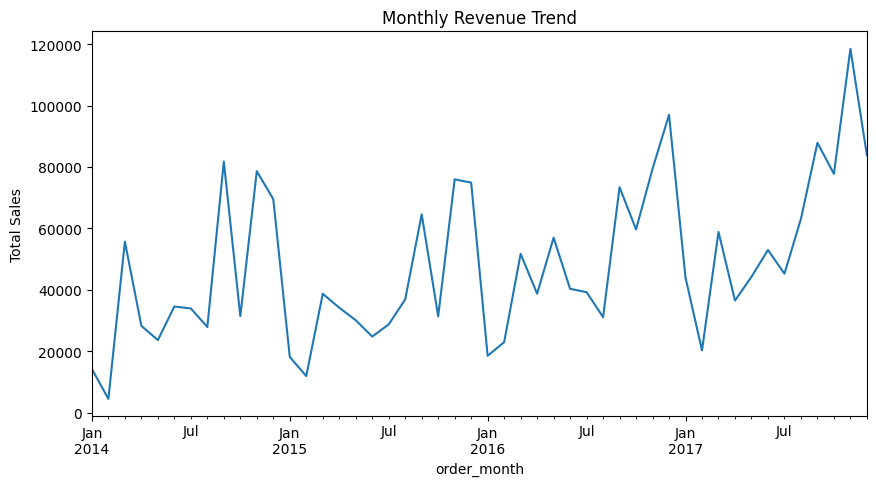

In [25]:
%pip install matplotlib
import matplotlib.pyplot as plt

monthly_sales = df.groupby('order_month')['Sales'].sum()

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.ylabel("Total Sales")
plt.show()


In [26]:
plt.savefig("../visuals/monthly_revenue.png")

<Figure size 640x480 with 0 Axes>

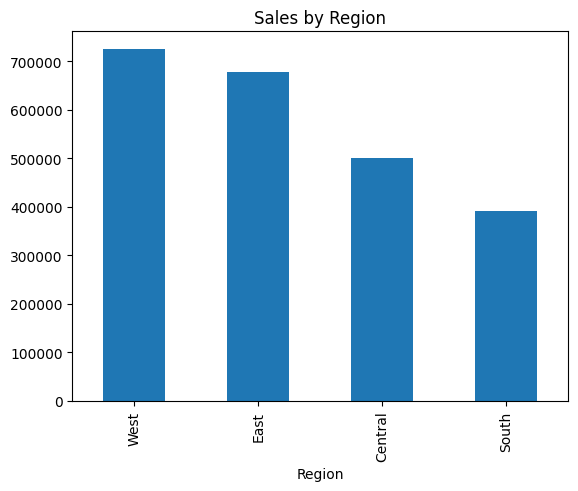

In [27]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.show()

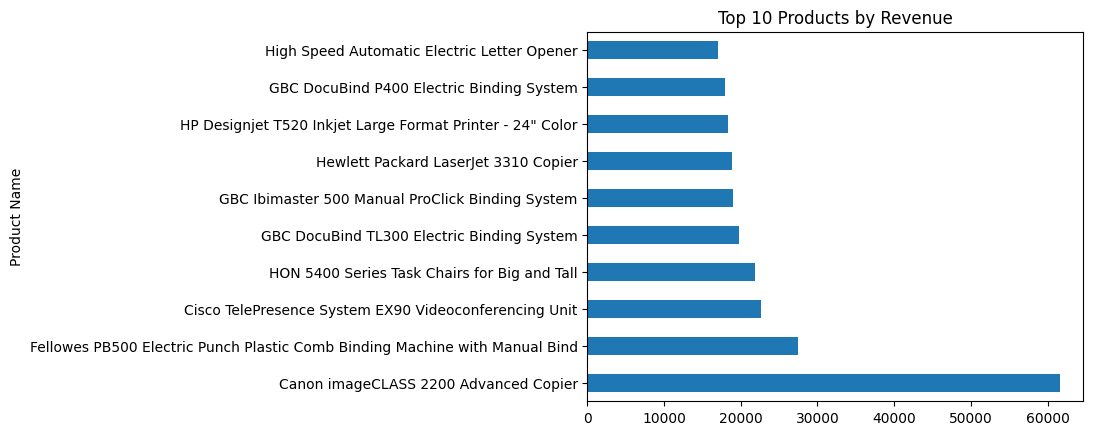

In [28]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh')
plt.title("Top 10 Products by Revenue")
plt.show()

In [29]:
aov = df['Sales'].sum() / df['Order ID'].nunique()
print("Average Order Value:", round(aov,2))

Average Order Value: 458.61


In [30]:
customer_orders = df.groupby('Customer ID')['Order ID'].nunique()
repeat_rate = (customer_orders > 1).mean()
print("Repeat Customer Rate:", round(repeat_rate*100,2), "%")

Repeat Customer Rate: 98.49 %


In [31]:
%pip install scipy
from scipy.stats import ttest_ind

region1 = df[df['Region'] == 'West']['Sales']
region2 = df[df['Region'] == 'East']['Sales']

stat, p_value = ttest_ind(region1, region2)

print("P-value:", p_value)


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
P-value: 0.42148160062316153
